In [1]:
import json
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from common import *
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def save_per_layer_predictions(v_copy_arr, plot_name):
    # aggregate a scalar summary per layer for each sample in v_copy_arr
    per_layer_vals = {}
    for sample in v_copy_arr:
        if isinstance(sample, dict):
            items = sample.items()
        else:
            items = enumerate(sample)
        for k, v in items:
            # convert tensor/array to a single scalar (use mean absolute)
            if isinstance(v, torch.Tensor):
                val = v.detach().cpu().abs().mean().item()
            else:
                try:
                    arr = np.array(v)
                    val = float(np.abs(arr).mean())
                except Exception:
                    continue
            per_layer_vals.setdefault(str(k), []).append(val)

    if not per_layer_vals:
        print("No per-layer values to plot.")
        pass
    else:
        # ensure consistent ordering (try numeric if possible)
        names = list(per_layer_vals.keys())
        try:
            names = [n for n in sorted(names, key=lambda x: int(x))]
        except Exception:
            names = list(names)

        # compute mean per layer
        means = [np.mean(per_layer_vals[n]) for n in names]

        plt.figure(figsize=(8, 4))
        # plot each sample as a light line
        n_samples = len(next(iter(per_layer_vals.values())))
        for i in range(n_samples):
            ys = [per_layer_vals[n][i] for n in names]
            plt.plot(names, ys, color="gray", alpha=0.3, linewidth=0.8)
        # plot mean
        plt.plot(names, means, marker="o", color="red", linewidth=2, label="mean")
        plt.xlabel("Layer")
        plt.ylabel("Mean |prediction|")
        plt.title("Per-layer predictions across samples")
        plt.legend()
        plt.tight_layout()
        if DRAW_PLOT:
            plt.show()
        else:
            os.makedirs("./gpt", exist_ok=True)
            plt.savefig(f"./gpt/{plot_name}.png", dpi=150)
        plt.close()

In [3]:
model_name = "openai/gpt-oss-20b"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, output_hidden_states=True, output_attentions=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

[transformers] MXFP4 quantization requires the `kernels` package: `pip install kernels>=0.12.0`. We will default to dequantizing the model to bf16.
[transformers] The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 411/411 [00:49<00:00,  8.35it/s]


GptOssForCausalLM(
  (model): GptOssModel(
    (embed_tokens): Embedding(201088, 2880, padding_idx=199999)
    (layers): ModuleList(
      (0-23): 24 x GptOssDecoderLayer(
        (self_attn): GptOssAttention(
          (q_proj): Linear(in_features=2880, out_features=4096, bias=True)
          (k_proj): Linear(in_features=2880, out_features=512, bias=True)
          (v_proj): Linear(in_features=2880, out_features=512, bias=True)
          (o_proj): Linear(in_features=4096, out_features=2880, bias=True)
        )
        (mlp): GptOssMLP(
          (router): GptOssTopKRouter()
          (experts): GptOssExperts()
        )
        (input_layernorm): GptOssRMSNorm((2880,), eps=1e-05)
        (post_attention_layernorm): GptOssRMSNorm((2880,), eps=1e-05)
      )
    )
    (norm): GptOssRMSNorm((2880,), eps=1e-05)
    (rotary_emb): GptOssRotaryEmbedding()
  )
  (lm_head): Linear(in_features=2880, out_features=201088, bias=False)
)

Layers: 25
torch.Size([1, 13, 2880])
[-0.017625605918339646, 0.03305537109701034, 0.06645079718695757, 0.08264483753432665, 0.10137421045547806, 0.15599419194408815, 0.18248519897460902, -0.9642192221095577, -0.9415048925285584, -0.8929445380838551, -0.9220466809395111, -0.7399645552675992, -0.7152055789262974, -0.6010593381702429, -0.5530473236344838, -0.6582707070896733, -0.7205780811798856, -1.170793047521883, -0.021092367579794585, 0.34227263621795345, 1.0841340415498113, 1.6270967923677853, 1.9393741444644625, 2.281993246486028, 0.06874510172085835]


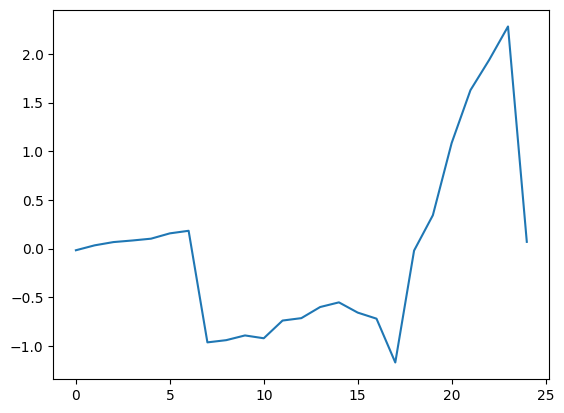

Layers: 25
torch.Size([1, 17, 2880])
[-0.012864097387657874, 0.0373764433891941, 0.06582178851358288, 0.09181126301584609, 0.0851257748073999, 0.12579388836630057, 0.14643815483143005, -0.7084280462826056, -0.6977742737414779, -0.6245487213134769, -0.6601738724054268, -0.48717651367187853, -0.6027518278633158, -0.5205239688648963, -0.5064654780369143, -0.6528462727864601, -0.8644333085203555, -1.1659089032341277, -0.41392024420445556, -0.14442661260467676, -0.03353123883016396, 0.14429772071589259, 0.165745733921827, 0.26216574276195626, 0.04128433707492769]


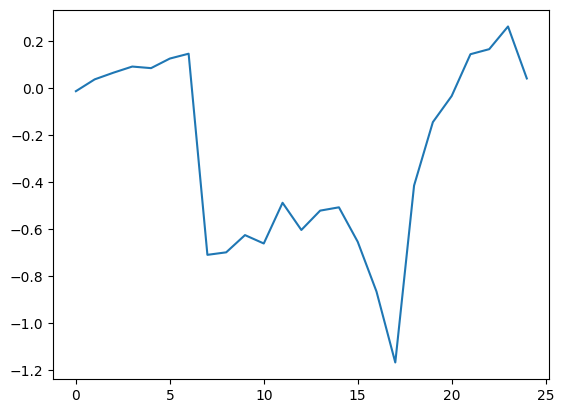

Layers: 25
torch.Size([1, 13, 2880])
[0.008108639156517517, 0.05333193000565235, 0.08683105696979737, 0.1170648884569479, 0.12263590820834132, 0.18283414596166522, 0.2292157702975781, -0.9071035010182998, -0.8749762771476235, -0.8393050104124826, -0.8189592149522473, -0.5764567905002151, -0.5626792712089215, -0.5298788429325547, -0.5497264747945624, -0.5124761076055009, -0.6305197691306097, -0.7878921247955076, 0.19338196322449258, 0.879760090102498, 1.4650887774605834, 2.403909849509193, 2.9505785819811985, 2.641241089910533, 0.07014820952700812]


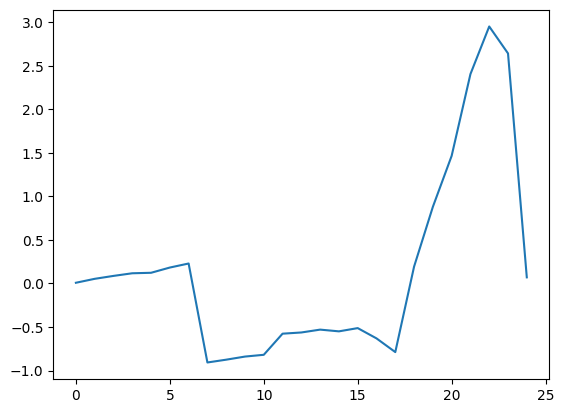

Layers: 25
torch.Size([1, 19, 2880])
[-0.027885243987013492, 0.025783612574750158, 0.05162879653841438, 0.09076121006792784, 0.11820634206136037, 0.1885017038088816, 0.23031712359155174, -0.48864191624156195, -0.46869138751114997, -0.3749180944342453, -0.3163042325025469, -0.08318170915571087, -0.07010108992370044, 0.015993816531884048, 0.02769408644291488, 0.025872369955855675, -0.09545909145422939, -0.23728386059141754, 0.49915278919955736, 0.5789671780770257, 0.010685399819534801, -0.02779469629477585, -0.11541569581505662, -0.3727439835754756, 0.028034622906244384]


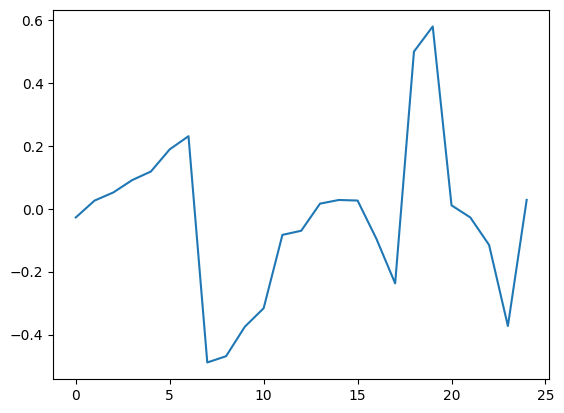

Layers: 25
torch.Size([1, 15, 2880])
[-0.003361362775408288, 0.04832751256448276, 0.07013716697692812, 0.1116619717633286, 0.12365907880994927, 0.19718307636402457, 0.23879232053403332, -0.7202351767928563, -0.7057520068133295, -0.6030415089925197, -0.5764876725938669, -0.30027401959453925, -0.39323742336696693, -0.31672414709020513, -0.36692335340710774, -0.44802849663629274, -0.5775060809100038, -0.9758757414641254, 0.24480995460792698, 0.7256110523365155, 0.6638123462818317, 1.5477253779658726, 1.9376948603877207, 2.208931070963551, 0.09374348216586657]


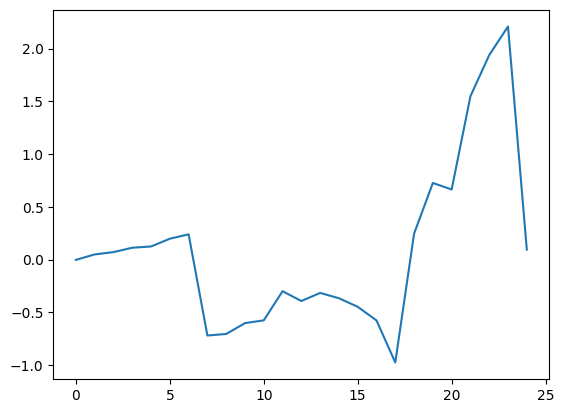

Layers: 25
torch.Size([1, 12, 2880])
[-0.012789172065121947, 0.03455639945136175, 0.061032713784112395, 0.10200661729883247, 0.1154960844251843, 0.12331741827505555, 0.179134736237703, -1.0277905676100039, -1.028774483998605, -0.9686955981784487, -0.9101558402732373, -0.6519053282561054, -0.7134906415586003, -0.607284983882201, -0.692296833462171, -0.8075123257107157, -0.9587268970630517, -1.3055698818630639, -0.2471920437283013, 0.261194992065433, 0.5897423638237863, 0.964457080982351, 1.3194171764232527, 1.2269796865957834, 0.05524318712177141]


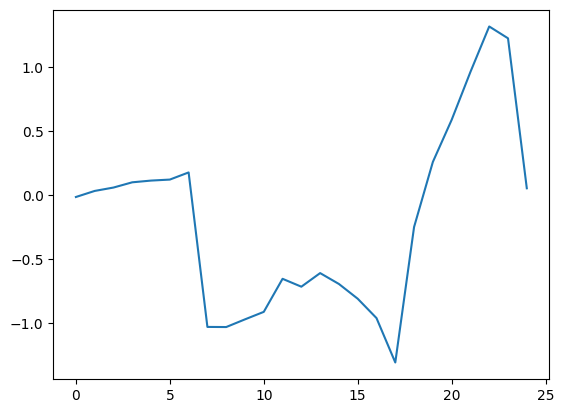

Layers: 25
torch.Size([1, 25, 2880])
[-0.01857950410826338, 0.022942768785688534, 0.04988519922892251, 0.06516242048475458, 0.06932373174031563, 0.1292199130588109, 0.17169847446017913, -0.39720676337346866, -0.37372693888347774, -0.30221535407172295, -0.2746783955891956, -0.08868662516276757, -0.05095684814452757, -0.05806998613146595, -0.11534585910372938, -0.24430541992186633, -0.47360626559787755, -0.5764737786187123, -0.4019396972656243, 0.20098345269097365, 0.6737422688801964, 1.2195478515624971, 0.8726719563802083, 1.0709501953124798, 0.05527318143844571]


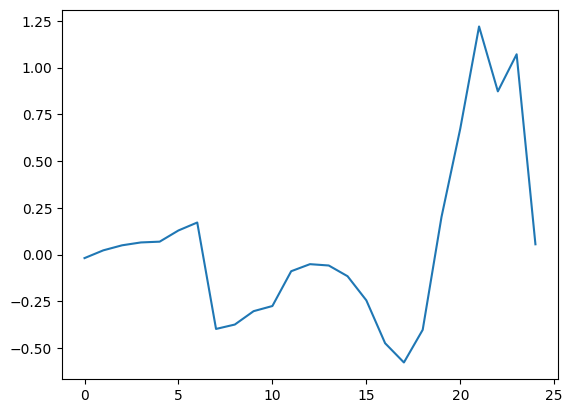

Layers: 25
torch.Size([1, 16, 2880])
[-0.012467481416630935, 0.03869736426406453, 0.07557926045523701, 0.10896756913926806, 0.12205988301171139, 0.1703491078482744, 0.24143006536695527, -0.6502056280771868, -0.6203292316860421, -0.5529628064897247, -0.5444941202799459, -0.3223521974351646, -0.3729262034098376, -0.3110598524411605, -0.3570167316330872, -0.3709209865993869, -0.3906465477413518, -0.7173039118448842, -0.044224982791476845, 0.4532271703084328, 0.5452079561021581, 0.2644966761271149, 0.2546240912543359, -0.3158236185709582, 0.025181679096486637]


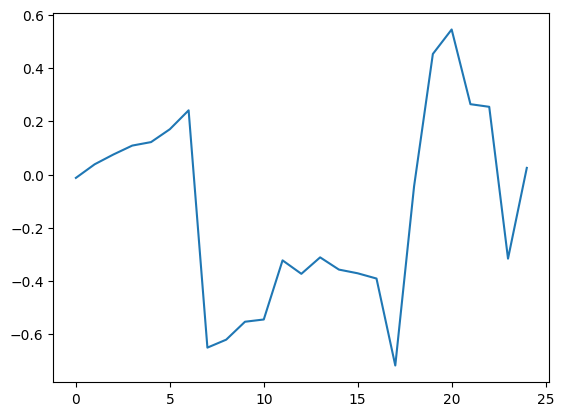

Layers: 25
torch.Size([1, 20, 2880])
[-0.008211682587344659, 0.04323390232192177, 0.07768215550316729, 0.12210137261284672, 0.16960155540042215, 0.2298118771447085, 0.27484809027777957, -0.4030408986409633, -0.3793303638034397, -0.2591530524359693, -0.24556162092420564, -0.05166033426920967, -0.10843596140542912, -0.046058290269648895, -0.16397118462456697, -0.3164424981011393, -0.6266245778401812, -0.9953104146321715, -0.4294318983289932, -0.2046317545572924, 0.1466598510742189, 0.7911506991916262, 1.8513231065538098, 2.0129646131727466, 0.0773874571588306]


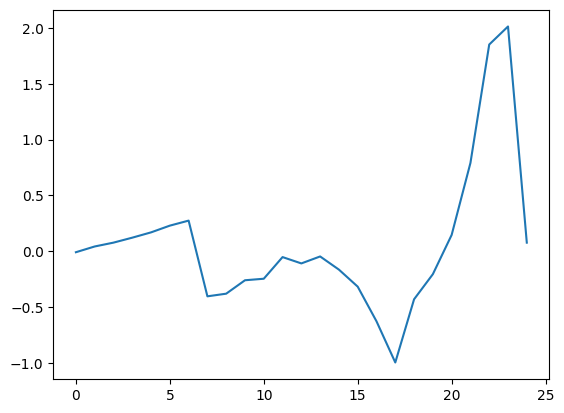

Layers: 25
torch.Size([1, 19, 2880])
[-0.01972892782977682, 0.021292903409366706, 0.0544328750922665, 0.08370953331216788, 0.092129766453079, 0.1312195069608633, 0.16330207356235443, -0.6043054145679041, -0.6082376223558592, -0.5618708694190145, -0.5580196849086813, -0.4038487038417179, -0.4435048331991237, -0.3631352028651551, -0.48290715803180273, -0.5944665027640812, -0.718460475631632, -1.032089019239973, -0.3245509632846725, 0.18270792375531156, 0.31151199786983563, 0.99634834869564, 1.1992074709886598, 1.1036278083310584, 0.04339121698636067]


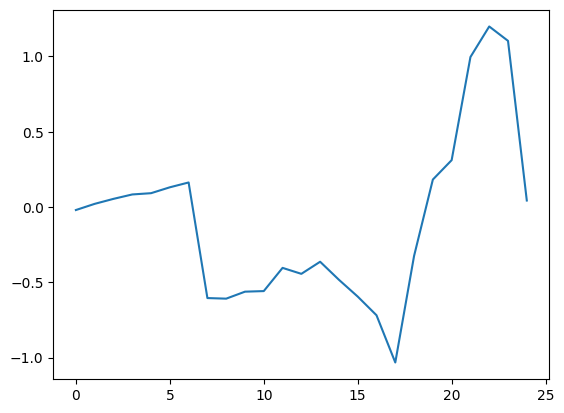

Layers: 25
torch.Size([1, 17, 2880])
[-0.0186451354351659, 0.017127719268300395, 0.057331211426678436, 0.06333681991676891, 0.07967543757818932, 0.13068592221129122, 0.1770197537989391, -0.6540795669057, -0.6296887840320882, -0.5834579617369386, -0.5385874978856984, -0.343270235747289, -0.48405398699192764, -0.35661924274917695, -0.30954855127272646, -0.22675022299773312, -0.38980186312806586, -0.8199637419258189, -0.30163388719745826, -0.14639803817848515, 0.11059161416845946, 0.38211546255872286, -0.12127892986621863, -0.6287557763990995, 0.013590476325914244]


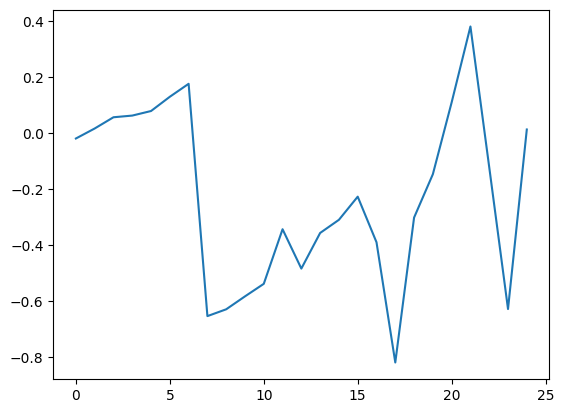

Layers: 25
torch.Size([1, 24, 2880])
[-0.01987361331735469, 0.02862256412152867, 0.05841225628499621, 0.07817756842683883, 0.08501105131926463, 0.1346725874476963, 0.15297286068951646, -0.4453935446562626, -0.4432934796368727, -0.4031835891582353, -0.4703958193461029, -0.2942582112771432, -0.3682670063442568, -0.22584470113118138, -0.2963810108326026, -0.35740553538005615, -0.6560759085196072, -1.0278966974328974, -0.5324720453333, -0.41629857663754816, -0.5761140752721736, -0.23467022931134238, -0.6256025102403399, -1.294772677951397, 0.018063879978877446]


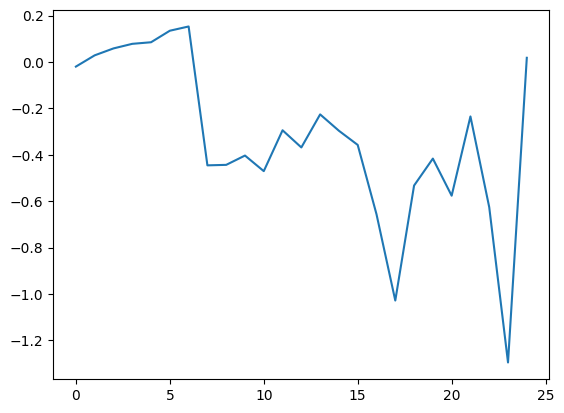

Layers: 25
torch.Size([1, 18, 2880])
[-0.0265468848475405, 0.021163767796975454, 0.05132112974001995, 0.08521081135596725, 0.10356716933073833, 0.13813096387886722, 0.17188705279503252, -0.6301789154241016, -0.6310629832891778, -0.5778740435470744, -0.510340462201903, -0.3358922652256396, -0.37493543271666574, -0.21195866678967126, -0.287967335736308, -0.4009952686451059, -0.4867689909758376, -0.7546149077238785, 0.05161586808569492, 0.5923126597463371, 0.8724346396363839, 1.394868563428332, 1.5137094756703255, 1.4113167468412309, 0.056459773433061855]


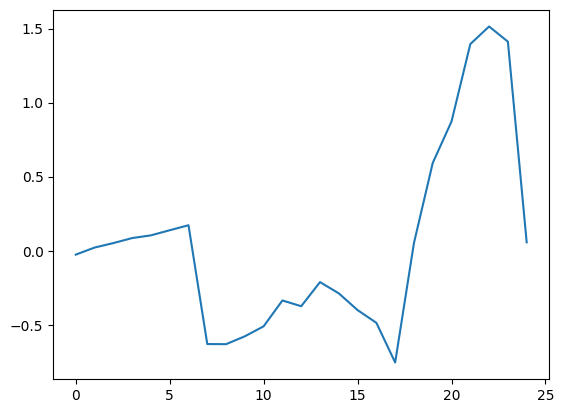

Layers: 25
torch.Size([1, 11, 2880])
[0.013252197640402391, 0.06797598781007683, 0.114929099034782, 0.1566312857348509, 0.17531129470979265, 0.2592732583633572, 0.32674546289925804, -0.9835476884938191, -0.9239663711702029, -0.8077354122894068, -0.8084437360667482, -0.4779795020517552, -0.4537147444908145, -0.28812004050823325, -0.2925479137536314, -0.22605735701742888, -0.43813658434936115, -0.8443472197561697, 0.42662350433041046, 0.6565724382496855, 1.137324785945386, 1.5388695302635784, 0.8192352603180287, 0.4300648082386302, 0.04901086682021045]


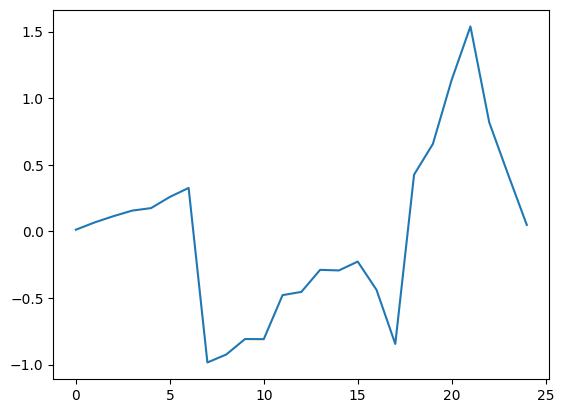

Layers: 25
torch.Size([1, 18, 2880])
[0.006501661890968245, 0.05497118602564295, 0.08618994553883813, 0.13071587291764722, 0.14002905833868293, 0.20014285570309187, 0.2112622743771408, -0.556235289868018, -0.5487881366117503, -0.44074485213668063, -0.4270405498551805, -0.195432625287842, -0.19397622567635844, -0.12347323570723137, -0.194884735860947, -0.24696971281075028, -0.43190092863859114, -0.7614042494032102, -0.17884376431688911, 0.06129206904658498, 0.07677994716314565, 0.5135800302764525, 0.27985806877230773, 0.22545271508487932, 0.04675707427071961]


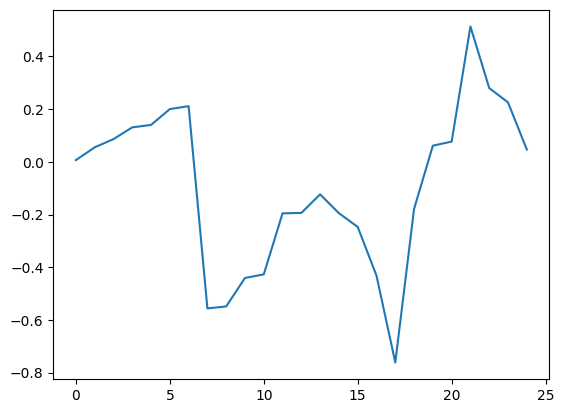

Layers: 25
torch.Size([1, 12, 2880])
[-0.014584225775561947, 0.02540841809025517, 0.05711024602254227, 0.08387546804216164, 0.1049467228077075, 0.1410338295830631, 0.1919523627669726, -1.006024162857627, -0.9811925958704034, -0.9023022863600012, -0.8492454034310701, -0.6257544340910676, -0.6707950945253596, -0.564481608072925, -0.47568997983578587, -0.536935311776627, -0.6736827567771424, -0.9455268577293106, 0.16347300211588472, 0.4442731221516952, 0.4512910065827538, 0.7708547521520658, 0.08029672128182866, -0.5219162552445019, 0.014084810294486999]


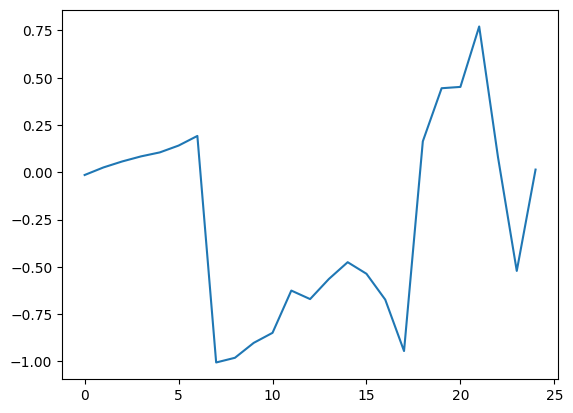

Layers: 25
torch.Size([1, 15, 2880])
[-0.0019129792245587203, 0.03726142274008856, 0.06475797582555723, 0.09396730352331115, 0.0873463185628257, 0.13338548448350693, 0.18121526930067303, -0.7745972018771747, -0.7416307972095637, -0.6713864616111391, -0.6152241742169307, -0.385118487322776, -0.4121639449508188, -0.3234513572410209, -0.35149254692926135, -0.4781069268120578, -0.5192289225260436, -0.6826105640552688, 0.3105595228407137, 0.7678094708478017, 1.0789949092158493, 1.2641822193287136, 1.7127816659432775, 1.9819802517360987, 0.06834627893235949]


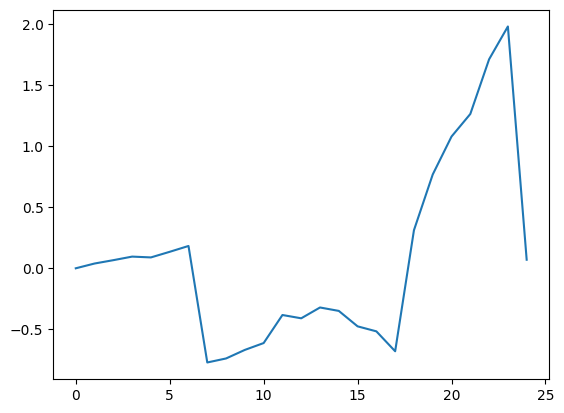

Layers: 25
torch.Size([1, 31, 2880])
[-0.012047550824093568, 0.03871124329105518, 0.0670393518222282, 0.09732694352399535, 0.11720330057178241, 0.1366043412129939, 0.1628011173672144, -0.2526455657029256, -0.27759496080405865, -0.20680623618505148, -0.09470986260308385, -0.024855952109057573, -0.054356909310945015, -0.04179329820858916, -0.005643487745709136, -0.16771043893685028, -0.29934210008190304, -0.6560013665093058, -0.13903199336007488, 0.19521625477780563, -0.08597418672294938, 0.4346790163320327, -0.14371452741724883, -0.22464154424633004, 0.03212838860822791]


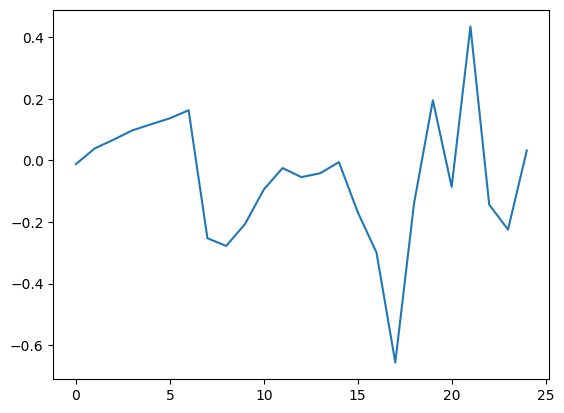

Layers: 25
torch.Size([1, 18, 2880])
[-0.006636903173560396, 0.04077860823384035, 0.06874931388431121, 0.10618324809604186, 0.09968750800615478, 0.15974300290331334, 0.18316851721869482, -0.6080487616268383, -0.554182024355295, -0.4994778385868775, -0.49988185741283325, -0.312170151133589, -0.25972134154519355, -0.16511470182442378, -0.2660535953662792, -0.4188726707741182, -0.5534664483717877, -0.6729693000699268, -0.019063916618442065, 0.17732318831079066, 0.4923360565562282, 1.0630050470799528, 1.2701244966483083, 0.5698751567322647, 0.04171910977658025]


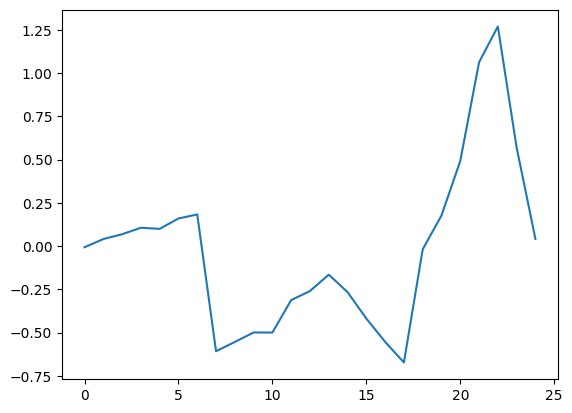

Layers: 25
torch.Size([1, 13, 2880])
[-0.01848390480149218, 0.02591986004103965, 0.06446126139062158, 0.08901124448857725, 0.11573198269575126, 0.17329936557346043, 0.2303846147325316, -0.8892602056519531, -0.8289011083097537, -0.7395473382411756, -0.7125087314181894, -0.44467659974710716, -0.45187784830729033, -0.4290600116436214, -0.4638041439219368, -0.5443002945337664, -0.6289942032251764, -0.6954897627871286, 0.6364412226228632, 0.9407695020365858, 1.533545052291997, 2.5802734114166146, 3.533001343816801, 3.629010896601223, 0.1076932090979361]


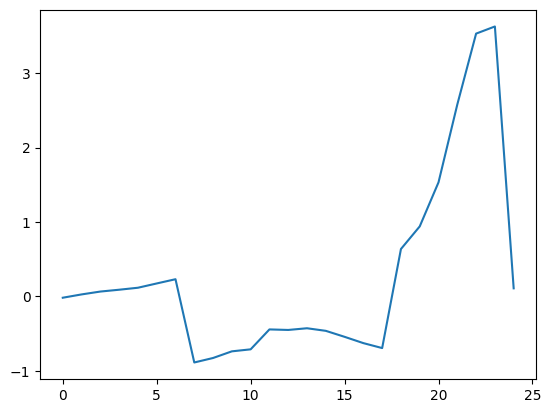

Layers: 25
torch.Size([1, 11, 2880])
[-0.013946662240219475, 0.036946049603548914, 0.07453017186636895, 0.10715910063849544, 0.1251103430083305, 0.18157294687598724, 0.23818678807730634, -1.0633772339483716, -1.0479047678937776, -1.0163541466298662, -1.005738167810917, -0.738733033459596, -0.8017327395352433, -0.7741206005366189, -0.7826643664427366, -0.8029822455512123, -0.866622616546306, -1.0843642417830675, 0.47858230128432755, 1.1964663727114861, 1.3426098139599087, 1.6303163470643833, 0.9630868006234281, 0.1386975220959617, 0.02173246012793639]


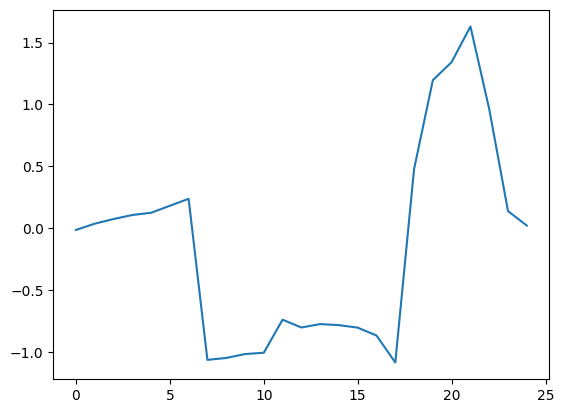

Layers: 25
torch.Size([1, 14, 2880])
[-0.027550035883905564, 0.011366284461248393, 0.027906813507988, 0.07034210855998657, 0.07651520835028752, 0.09665905483185265, 0.1399111399574876, -0.8986373961918012, -0.8717163570343394, -0.8171843362232839, -0.8693988073439796, -0.7245133960057825, -0.8250791277204177, -0.808011699858177, -0.9073443942599897, -0.9825750865633595, -1.0492386590866738, -1.2610021439809653, -0.0823610820467491, 0.5885455903552846, 1.2302762470548212, 2.043075319320425, 2.511296832372271, 1.716550602988544, 0.07933580149260826]


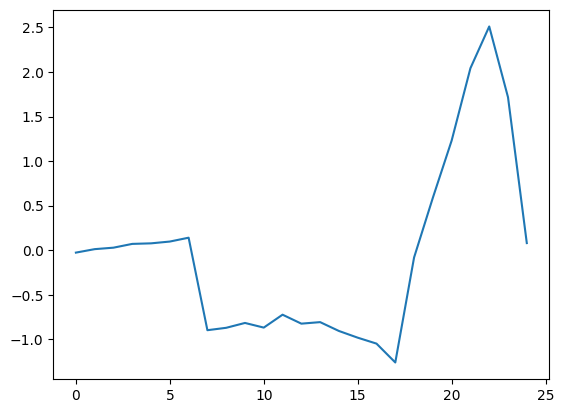

Layers: 25
torch.Size([1, 11, 2880])
[-0.01569126125856081, 0.03739753275206612, 0.06172041170524807, 0.09691311470185805, 0.11956998459016399, 0.17507052758727418, 0.17329450665098337, -1.1374911606913867, -1.1230209273521246, -1.082006431348397, -1.0900799221462611, -0.8883186725655169, -0.8485947040596358, -0.7169661088423345, -0.7962386160185942, -0.8877632834694628, -1.0459242078993098, -1.4782937406289431, -0.47829648412838927, -0.11570847636521327, -0.024231072628137666, 0.07421816430910617, 0.6099797412602721, 0.828926348445384, 0.054781803699454165]


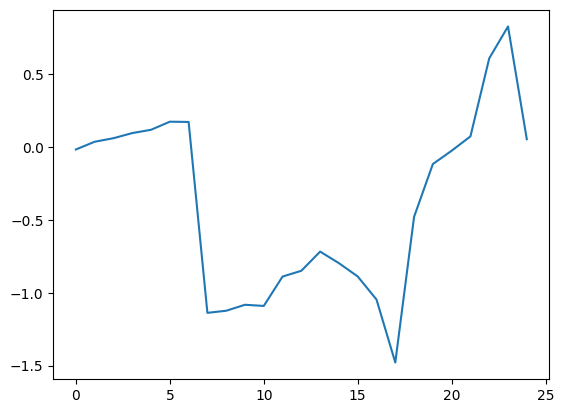

Layers: 25
torch.Size([1, 19, 2880])
[0.002623143003523722, 0.05053448914087325, 0.06969881671213995, 0.11735254588880019, 0.13680246364303322, 0.2060594859876143, 0.272145185414808, -0.47637392902931985, -0.40795020834047446, -0.3418338530244849, -0.33271205522859454, -0.08935009694239456, -0.12445448936776196, -0.04220974570826584, -0.15072705452902788, -0.31694107501827856, -0.43809262102807905, -0.9464072422674601, -0.23359731930738545, 0.13959311323556206, 0.29736285293311515, 1.0408899853801177, 1.1092150414896127, 1.3194024693896056, 0.06894256845552266]


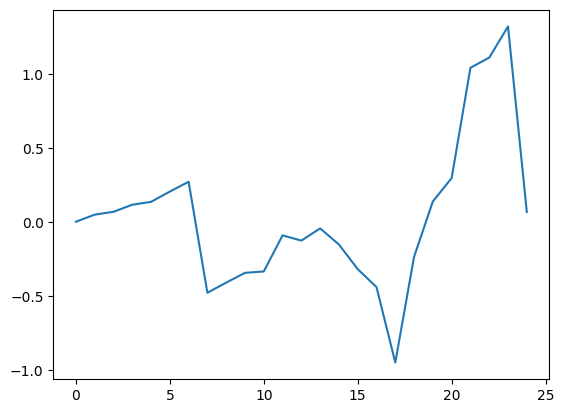

Layers: 25
torch.Size([1, 13, 2880])
[-0.0020196452900034904, 0.04881560496794866, 0.08524124601967319, 0.12872688994448325, 0.14033344953488097, 0.21471315530630286, 0.27914761274288874, -0.8016528594188188, -0.7681904262966438, -0.7222141950558375, -0.6427730984158089, -0.4850328885592039, -0.5308619702983153, -0.4422893165523184, -0.4152186793139828, -0.3454235892010583, -0.29571994879306385, -0.5503364236945594, 0.4948702559511889, 0.7717467218382722, 0.5222576956463655, 0.6051961784688927, 0.42095902923844847, -0.7646011222122023, 0.023982105092105653]


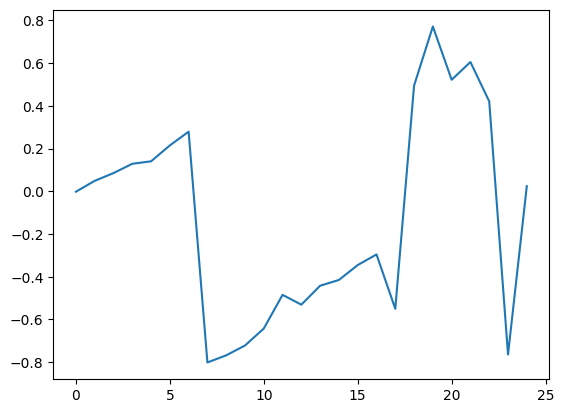

Layers: 25
torch.Size([1, 24, 2880])
[-0.015612671549940851, 0.03152882920371178, 0.06378063934820623, 0.09407353003819845, 0.10623964733547658, 0.13139386618578838, 0.14912536938985246, -0.42608482396161046, -0.4226695360960878, -0.3427770543981508, -0.34724944079363607, -0.22447850969101735, -0.2748914859913155, -0.18967735855666645, -0.33290576581601494, -0.42207558949789575, -0.757724620677797, -1.1488762113783288, -0.40290434095594435, -0.1405959729795078, -0.07354549831814296, 0.09315519686098675, -0.055481253729922145, -0.7658754278112349, -0.00043376927022581674]


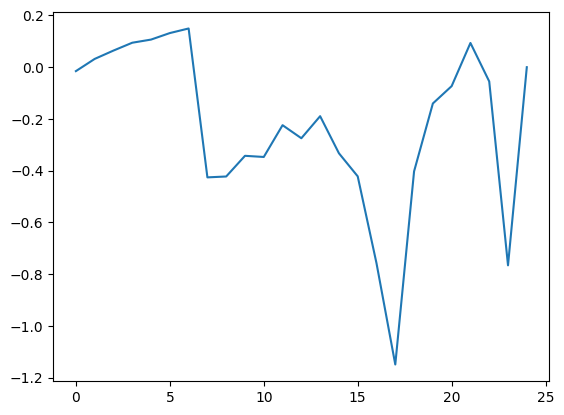

Layers: 25
torch.Size([1, 15, 2880])
[-0.008457401752195984, 0.039410213541101476, 0.08493960910373248, 0.09685324350992915, 0.1360336459124527, 0.1821438711660878, 0.2360827509562178, -0.7428074985080297, -0.7054077939634085, -0.6036601426866454, -0.5360266395851384, -0.3365592193603447, -0.40097040812174334, -0.31380618201361354, -0.37679872724745495, -0.3462185951515502, -0.4748976304795982, -0.7309411168981576, 0.13030090332030989, 0.7024939869068227, 0.9711717845775347, 1.07277153862848, 0.8250849066840225, 0.4338043438946795, 0.03542425296924715]


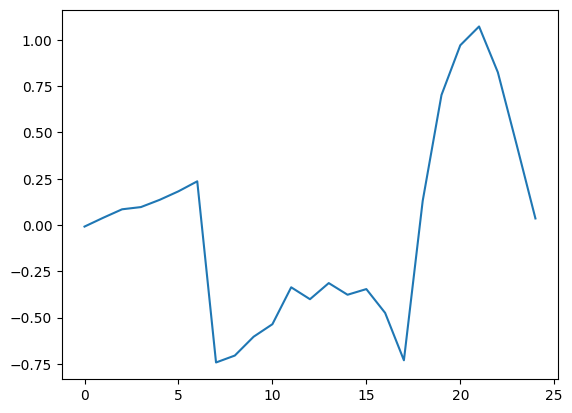

Layers: 25
torch.Size([1, 18, 2880])
[-0.007939846412980083, 0.04165830553313886, 0.09367928622681426, 0.1328492079252072, 0.1577451647063833, 0.21575089796089864, 0.2541757136215395, -0.5240297011387172, -0.5169261367232719, -0.43647229229961987, -0.4027594060073591, -0.11886994161723743, -0.14822052731926888, 0.00886537528332049, -0.030813987166794204, -0.19124715357651317, -0.2950907577703064, -0.5059762271833982, 0.32630100956669866, 0.5765171380690556, 0.11577960355782126, 1.3388979499722744, 0.6262820396894285, 0.7327706796151653, 0.04805701218637407]


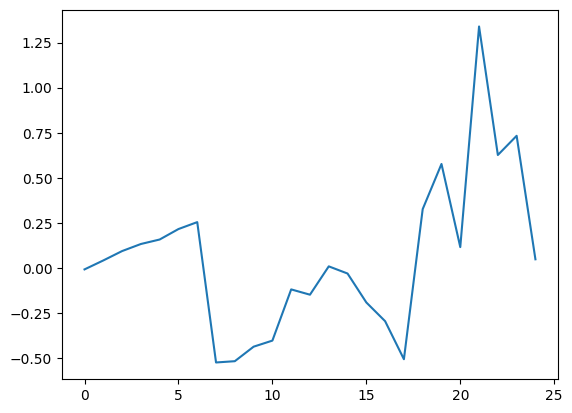

Layers: 25
torch.Size([1, 7, 2880])
[-0.011721287410528861, 0.028052809881785448, 0.07653415770757765, 0.11001430238996214, 0.11313097514803373, 0.17824556865389435, 0.22333126370868975, -1.8103663005526043, -1.781512911357585, -1.7275945996481064, -1.6729077778165358, -1.4207762460860063, -1.3984615023173996, -1.2993511866009293, -1.2978805784195109, -1.4027164519779252, -1.6344212607731878, -2.104867795913946, -0.2916594974578369, 0.12592215159582745, 0.22300812251984586, 0.8207515656001998, 0.9974812825520805, 1.4204584030877871, 0.049176256618802726]


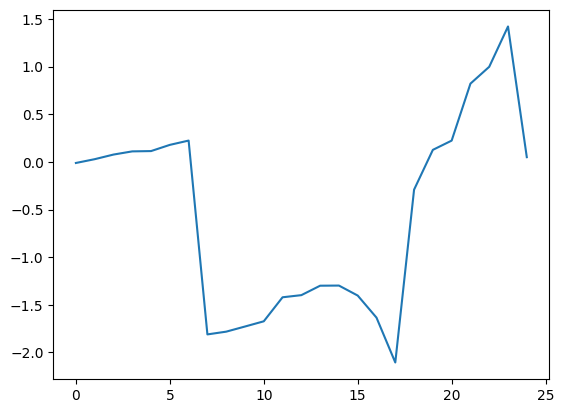

Layers: 25
torch.Size([1, 17, 2880])
[-0.01690174100534021, 0.03047208271774613, 0.05678408473145753, 0.09526325549954702, 0.10800995047575464, 0.14884370043386694, 0.18709378086663345, -0.6265799615897399, -0.6260254280239979, -0.5612182866514075, -0.4600289488150386, -0.2326915765899308, -0.19131683150147322, -0.012775136910229343, -0.03308967141543833, -0.09976231194789698, -0.23419382930580498, -0.43747562582975735, 0.11918520459941592, 0.41715544656990605, -0.11335612777012205, -0.15483893101511464, -0.5394278732000689, -1.5586322061376507, -0.005915745469479763]


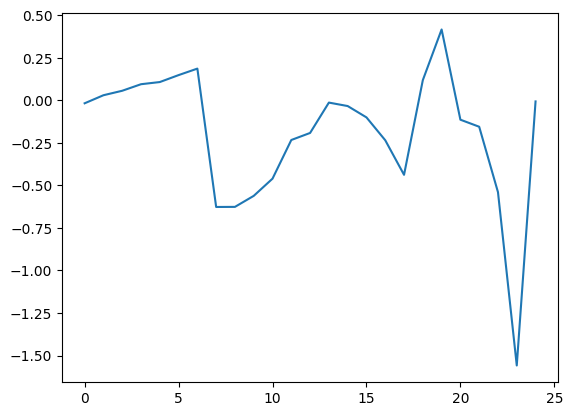

Layers: 25
torch.Size([1, 20, 2880])
[-0.024153125024943878, 0.023372878498501077, 0.057505670123630385, 0.09890465206570137, 0.10767957581414149, 0.17535197893778606, 0.2063677321539971, -0.5019543817308327, -0.45492124345567725, -0.35413171132405, -0.3349305873447037, -0.15062835693360038, -0.1838986714681009, 0.052005861070423376, -0.03533880445692321, -0.07202464633517107, -0.10705776638454576, -0.32397177802191784, 0.2206608581542977, 0.42944156222873625, 0.5422280544704818, 0.9338257175021717, 1.3430679999457062, 1.2811589898003504, 0.052401833600468295]


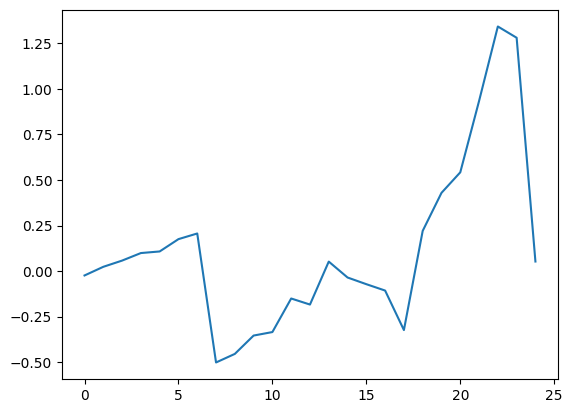

Layers: 25
torch.Size([1, 14, 2880])
[-0.004394521039452321, 0.03641294505861091, 0.05039976532497096, 0.08413602246178466, 0.08282500221615698, 0.1239624205089745, 0.17307652518862776, -0.8433531655205762, -0.807615470886229, -0.7764266846671877, -0.7724928598555282, -0.5637942722865427, -0.5777706388443242, -0.4464884288727228, -0.4604479956248462, -0.4972095307849933, -0.5718008132208037, -0.9748792739141582, -0.0916006088256846, 0.5126400417751744, 0.27317623562283166, 0.6369303869822803, 0.4319976322234608, 0.40390799386161147, 0.0339798343560054]


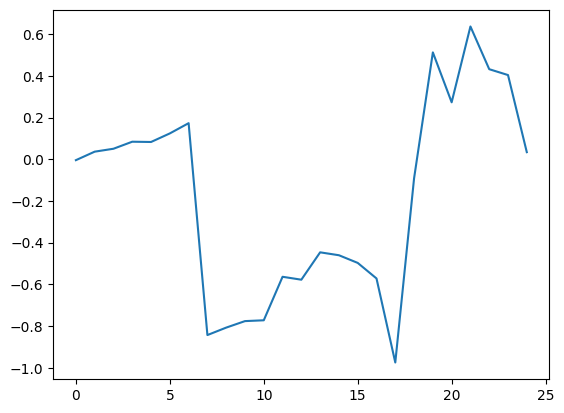

Layers: 25
torch.Size([1, 13, 2880])
[-0.012510222577067971, 0.025466611038925283, 0.06385778035873013, 0.07944339931520596, 0.1027213471567526, 0.11137621952937228, 0.13570155282305782, -0.9661035586626348, -0.9495647919483583, -0.9095823891142503, -0.8933361086071071, -0.7816394903720996, -0.8979708484095529, -0.8808568579518999, -0.8171873304578964, -0.9176856668586639, -0.986266646425945, -1.0272131895407912, 0.28251775757879205, 1.3526977017394444, 2.0792807032919156, 2.930173381577203, 3.530541470519507, 3.8101741432124556, 0.10495147868099367]


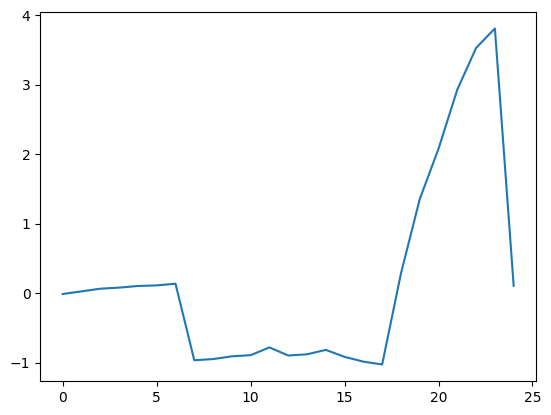

Layers: 25
torch.Size([1, 10, 2880])
[-0.0263660289849052, 0.016495107544793247, 0.042307606803046856, 0.0727812978956428, 0.08333477867974133, 0.1253719033135316, 0.17061153411865362, -1.302581299675838, -1.295381164550776, -1.228448672824442, -1.2525007629394511, -1.0122300593058307, -1.0980015224880904, -1.0173995886908709, -1.139733920627167, -1.3057081095377492, -1.4516346571180636, -1.8969366455078467, -0.3771062554253465, 0.079843207465278, 0.6606952243381033, 1.207963731553812, 1.814755113389766, 1.6841208224826418, 0.04258816997210195]


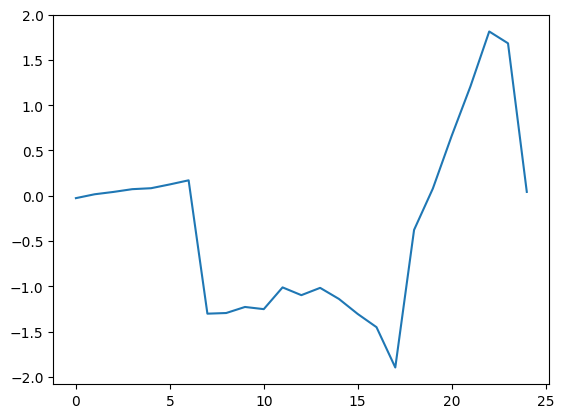

Layers: 25
torch.Size([1, 14, 2880])
[-0.005862243682153432, 0.04465094085723665, 0.06594289219568596, 0.10626937094188933, 0.14028876622517805, 0.20330490763225184, 0.21917875683497, -0.7952917765057264, -0.748245705498608, -0.6407618507506407, -0.6927257961697055, -0.43605497451055275, -0.38572031354146574, -0.32887073849876264, -0.3796224185398514, -0.2960765051463237, -0.44550689212858363, -0.586852833581349, 0.2720444936600934, 0.9944035121372651, 1.0797603062220893, 1.056608218238468, 0.3893866644965255, 0.3874373178633473, 0.0413539937564309]


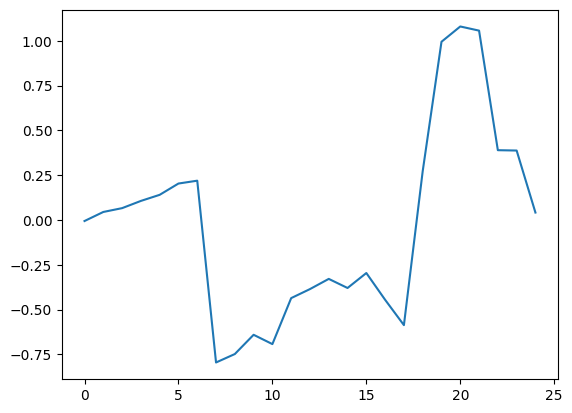

Layers: 25
torch.Size([1, 18, 2880])
[-0.025793613365098136, 0.009356570832523411, 0.028713416464535128, 0.058346601180088144, 0.05584548549887591, 0.0926132107958382, 0.10107436238983508, -0.7016586727566193, -0.6791939064308479, -0.6295969127136923, -0.6088677865487612, -0.463038093661075, -0.5436517786096694, -0.5372487338972738, -0.6021638752501928, -0.8078725555796569, -1.0571552512086548, -1.4312122297875838, -0.7082902131257249, -0.4478327621648351, -0.6970599139178268, -0.6771384345160573, -0.639632632408615, -0.635618045006271, -0.0006851397178794835]


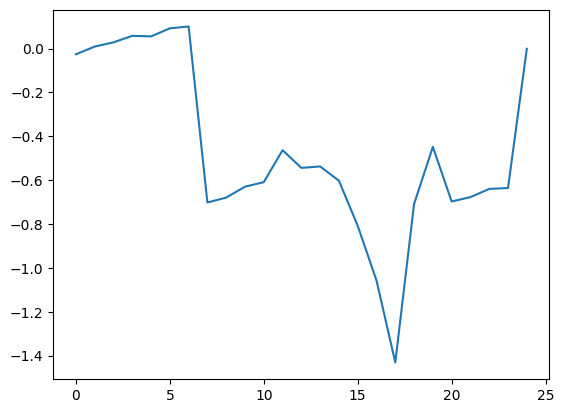

Layers: 25
torch.Size([1, 14, 2880])
[-0.01803817971173452, 0.032715225976611195, 0.051857970252869395, 0.06868428427075644, 0.07054878870646165, 0.12194445473807201, 0.16753526717897466, -0.8873922741602506, -0.8398073892744806, -0.7750947498139854, -0.8536003718300472, -0.672698017907511, -0.805515555729937, -0.7099145556253096, -0.8251442682175331, -0.9336979578411785, -1.1340138632153713, -1.2955909123496312, -0.25221514020647223, 0.10403670053633468, -0.06968093145460845, 0.30106147887213963, -0.11903657459077585, -0.8304729158916099, -0.013619253843549863]


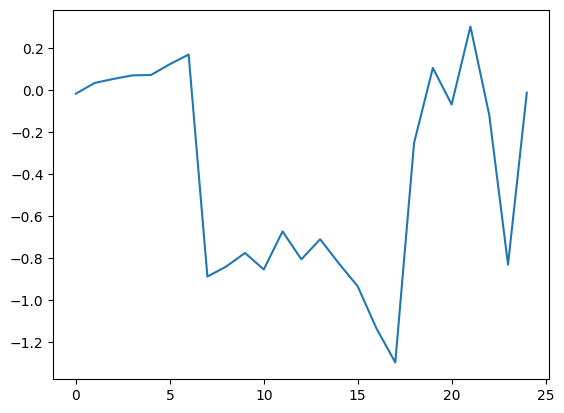

Layers: 25
torch.Size([1, 12, 2880])
[-0.023255968714322603, 0.021928631817853178, 0.030341289661548775, 0.06221602227952787, 0.07327140348928951, 0.10705823633405892, 0.16124405684294515, -1.0464110233165786, -1.0405439588758603, -1.0067229306256174, -1.0762607503820347, -0.9698595682779904, -1.0607138457121588, -1.0989591104012884, -1.36211313318322, -1.4721136022497123, -1.6070252595124404, -2.2764773898654633, -1.4852995413321075, -1.4581584506564675, -2.1019714638039084, -2.251385441532853, -2.408527854636873, -2.3339230007595724, -0.02142193758929203]


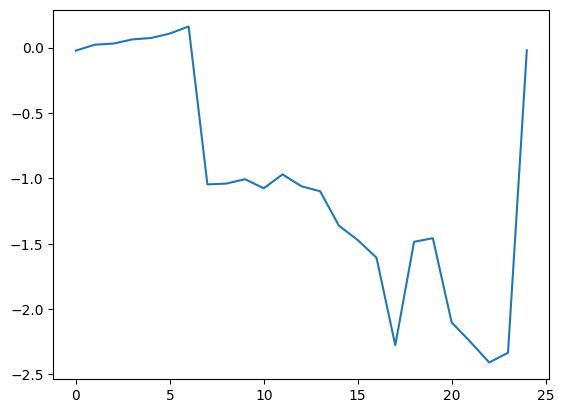

Layers: 25
torch.Size([1, 9, 2880])
[-0.02459847638124797, 0.0261598575262375, 0.05683536058590743, 0.0752132592377835, 0.09852028834966954, 0.1061217790768464, 0.15218404134114627, -1.471368992181471, -1.4618823392891611, -1.4237716015474344, -1.4141726081753911, -1.1725189585744622, -1.2454670470437814, -1.1554207224904813, -1.1760429288134286, -1.2891611735025954, -1.3662509117597346, -1.7214307243441234, -0.08473386411313646, 0.43382568359374757, 0.6416146737557787, 0.6794422290943358, 0.5393663947964918, 0.11670140395929451, 0.016946820712383986]


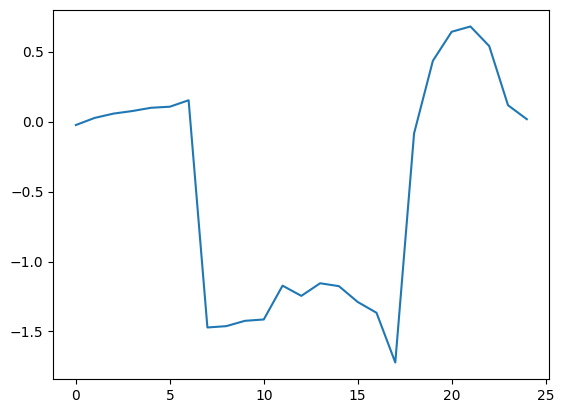

Layers: 25
torch.Size([1, 11, 2880])
[-0.012725144695735137, 0.024598450853367045, 0.04424617121918024, 0.0753855358470574, 0.0978331883748375, 0.14996726681487713, 0.1696461494522857, -1.152540808012987, -1.1627385303227618, -1.1373220462991762, -1.1624781521883945, -1.0324333884499406, -1.15203035913332, -1.139909678757782, -1.425071269333962, -1.5524618668989807, -1.7779610373757242, -2.130605092674811, -1.1041624127012324, -0.828238439078282, -0.8901787651909716, -0.2152045355902788, 0.1431072813091858, -0.06963710592250626, 0.01136419315530826]


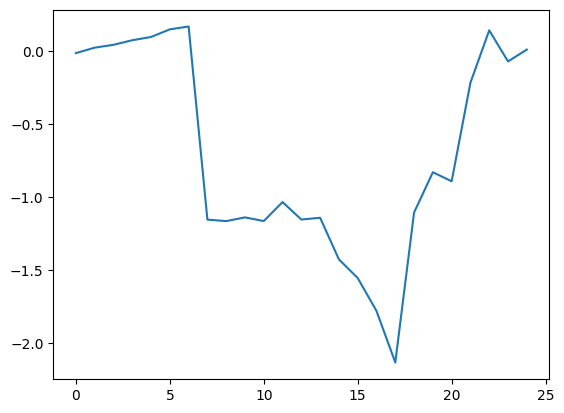

Layers: 25
torch.Size([1, 19, 2880])
[-0.02088823318563138, 0.02814467859547037, 0.0666886602925981, 0.10925738462927843, 0.12396461642973522, 0.1850238933897863, 0.22699535659879022, -0.5147680382979563, -0.4792446337248215, -0.43078944557590687, -0.46306745741102945, -0.29432891934936406, -0.33729849475169044, -0.2073332758674908, -0.3770194962707865, -0.4986600820084203, -0.5808548062865413, -1.0334919176603659, -0.1310699105959865, 0.7135439153303208, 1.1053026344343957, 1.8594537032278107, 2.2700713397466727, 2.798157166598117, 0.08594863282309614]


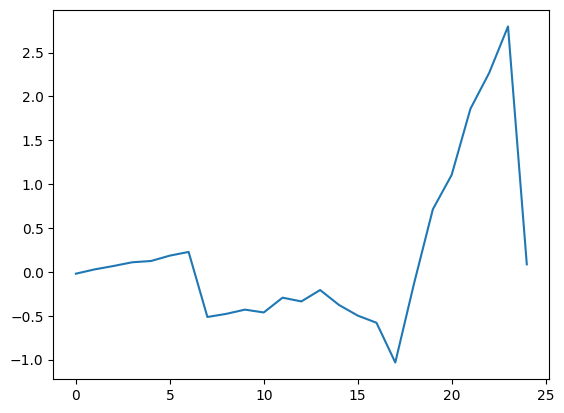

Layers: 25
torch.Size([1, 15, 2880])
[-0.010025105786992722, 0.030989918178982185, 0.06889759558218514, 0.11186803005359794, 0.1170059006302446, 0.16050503766095203, 0.20550866021050282, -0.7347143003675669, -0.7238297949896895, -0.6951190976743277, -0.6470103143762563, -0.4249517257125255, -0.4798192172580279, -0.4119922892252626, -0.4639886418095403, -0.44612761320891275, -0.5355301807544712, -0.9374336694788112, -0.3227572518807874, 0.692275447139044, 0.8351353624131965, 1.334143382884836, 1.5831170428240966, 1.815525625723392, 0.05788867305826309]


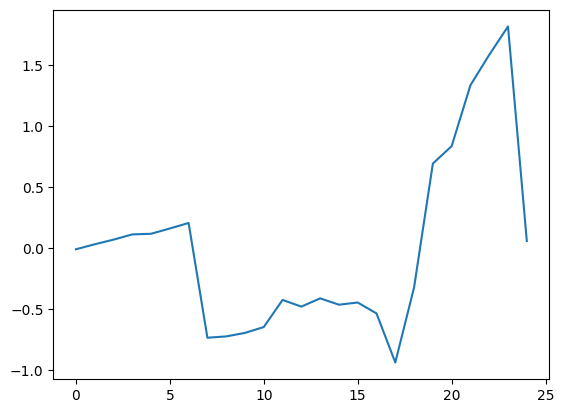

Layers: 25
torch.Size([1, 18, 2880])
[-0.025612608491109832, 0.01803479518419423, 0.04549946961579547, 0.08761609277607589, 0.11058098946088597, 0.15050174630718555, 0.163412025828422, -0.6284649754747977, -0.6169450665697774, -0.5645137551390226, -0.5948773372320607, -0.4036078276457648, -0.48679851013935965, -0.3896943645712723, -0.50143279087396, -0.6691258936752399, -0.8160431096583066, -0.963579983181414, -0.29115381123107537, 0.4217155644923044, 0.7472460122756012, 1.1268377421814744, 1.7468545984338848, 2.086618946216786, 0.06588158040870971]


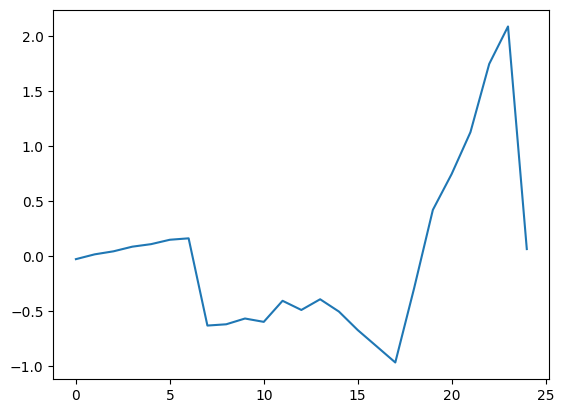

Layers: 25
torch.Size([1, 12, 2880])
[-0.029396253711483567, 0.0213372100282598, 0.06426318000864109, 0.10629824355796447, 0.13295726069697536, 0.1808690388997423, 0.24127755871525713, -0.9633582291779599, -0.9290336679529193, -0.8396650031760722, -0.8105220017609865, -0.588706235532408, -0.6277051784374154, -0.49766136452002563, -0.4932502746581982, -0.45586525245948734, -0.5555824562355367, -0.8432080586751249, 0.10157289858217652, 0.2925542760778352, 0.8406572129991257, 1.2568616513852668, 0.7540866427951284, -0.3157739709924723, 0.009260603233620386]


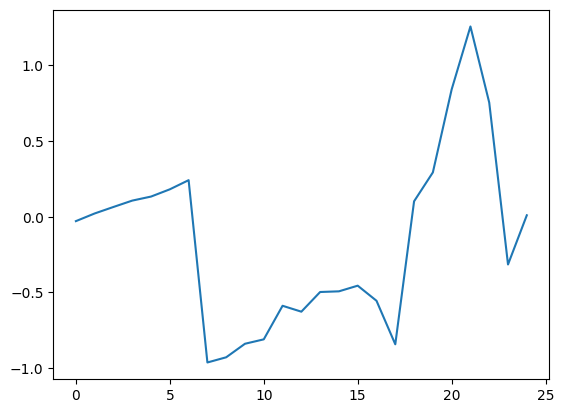

Layers: 25
torch.Size([1, 15, 2880])
[-0.024716254798695363, 0.028480155379683972, 0.03715116783424682, 0.0662696471037696, 0.08335706922743152, 0.1348439576890741, 0.1746189739086032, -0.7810126283433659, -0.7706950689245172, -0.7105294517234504, -0.7444421782317047, -0.5670966084798112, -0.628766767713764, -0.6335512401439644, -0.8074423556857604, -1.0031585806387349, -1.28627617730035, -1.8156858091001111, -0.9645000768590831, -0.6117574508101822, -0.3798927815755201, 0.01704128689236372, -0.30735957392939994, 0.1889384403935225, 0.038509618264657285]


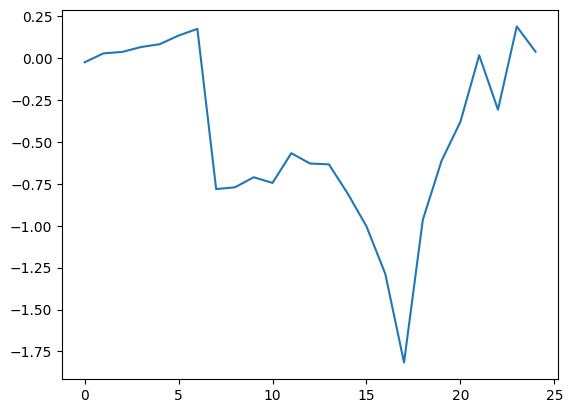

Layers: 25
torch.Size([1, 11, 2880])
[-0.005726305807404332, 0.044054422956524675, 0.08638291310782445, 0.14114583333333178, 0.1617700056596227, 0.2111241331004123, 0.27223005969114955, -0.9981392253529118, -0.9992934988002482, -0.9286545223660055, -0.8964436906756783, -0.6903295883024462, -0.8605927207253177, -0.790263913857817, -0.8768942784781331, -0.9661834100280153, -1.0079316880967908, -1.2212130768130627, 0.22272200150922944, 0.9208416871350346, 1.1071428395281049, 1.8409533259844517, 2.024439339685924, 1.2475467566288079, 0.06194884825234449]


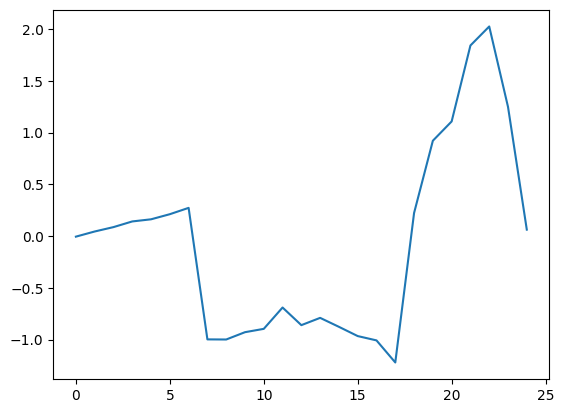

Layers: 25
torch.Size([1, 19, 2880])
[-0.005199362945263656, 0.040834729016175596, 0.07821273385432659, 0.12050974940696044, 0.12349768019559114, 0.18236760814287611, 0.22377251407556492, -0.5025317760935962, -0.4671212023461857, -0.42404660230492563, -0.4179150096157018, -0.27314695837901226, -0.2773187380785059, -0.21038544415033406, -0.15110071193405902, -0.05465401989673479, -0.22457199542843737, -0.3880267583835894, 0.15194775319238923, 0.5843504788582803, 1.1199930826822893, 0.927691953781753, 0.6552664059644422, 0.08665607296232984, 0.031524786265969884]


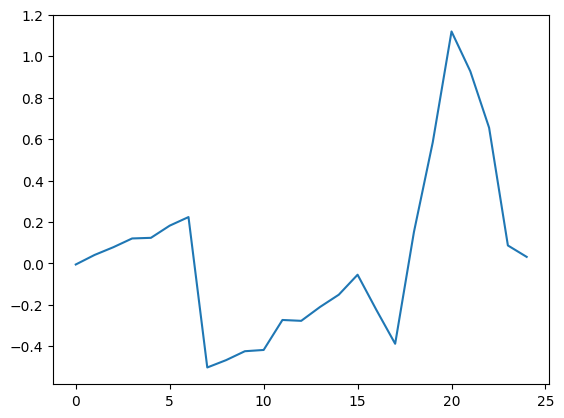

Layers: 25
torch.Size([1, 8, 2880])
[-0.021098047265938214, 0.03771684434678827, 0.08250366515583472, 0.1322059339947177, 0.1696500009960594, 0.24428651067945628, 0.2954634083641893, -1.5139387554592607, -1.4554050419065656, -1.3656651920742373, -1.2986081812116774, -1.0467192755805048, -1.126196416219065, -1.1009216652976024, -1.0540270037121262, -1.1228125678168372, -1.1412172635396347, -1.3385691324869733, 0.5968783060709637, 1.346876313951284, 2.188589265611429, 2.7115585539075946, 2.291780927446155, 2.3516644795735964, 0.08060775597890138]


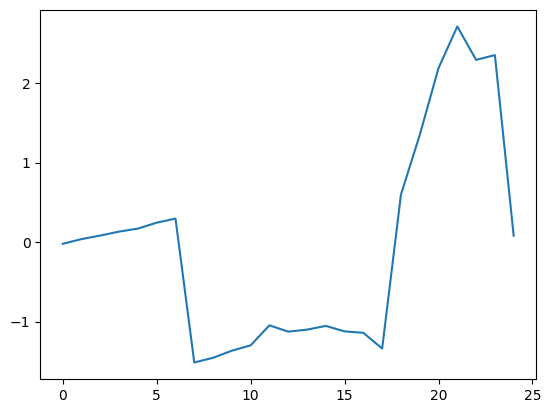

Layers: 25
torch.Size([1, 22, 2880])
[-0.02113165900033565, 0.013369786378109032, 0.03991685250792798, 0.0650375476991285, 0.0526111097046827, 0.09627925314084418, 0.11626849126334195, -0.5370595912740819, -0.5416074829872314, -0.5045374899199551, -0.47519749342793394, -0.3449508243136897, -0.45637811988292704, -0.4789426745790419, -0.6055226932872313, -0.7956281565656689, -0.9696406894259983, -1.221274574356835, -0.5515789147579313, -0.6085862593217283, -0.5460164079762448, -0.5045503250276226, 0.1258329757536273, 0.8535497800268453, 0.04969599830983898]


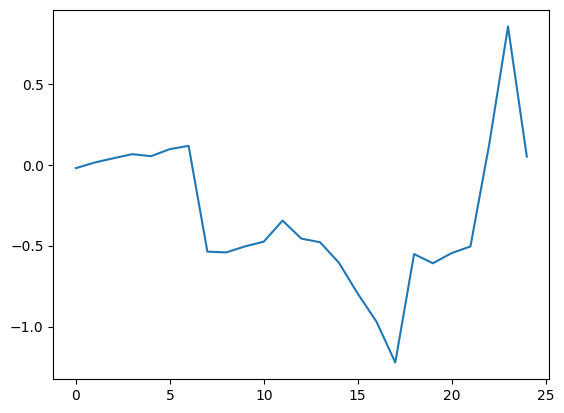

Layers: 25
torch.Size([1, 17, 2880])
[-0.01431406497714907, 0.03876946829502857, 0.06846180834801446, 0.10398142166386964, 0.10900308571609832, 0.13916842018077608, 0.16009657242718747, -0.6978019851485144, -0.6729248271269052, -0.6068680657280787, -0.5695898716745784, -0.332984610164869, -0.3921101738424876, -0.2838130876129806, -0.29434792512382485, -0.3426939222547707, -0.5843291837405428, -0.8367772320516506, -0.11118849710701127, 0.2558691186842545, 0.4796197429981092, 1.4281387428832368, 0.8045640334584289, 0.3793978821997616, 0.037914914671891405]


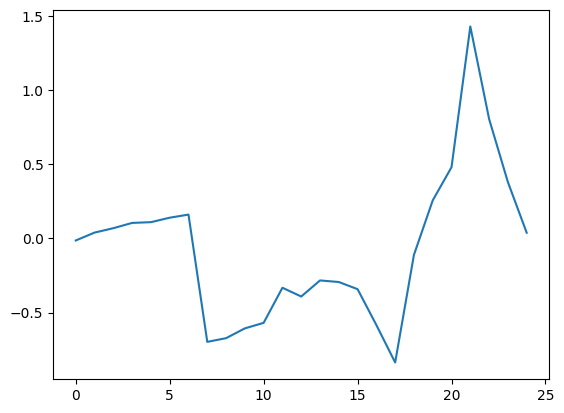

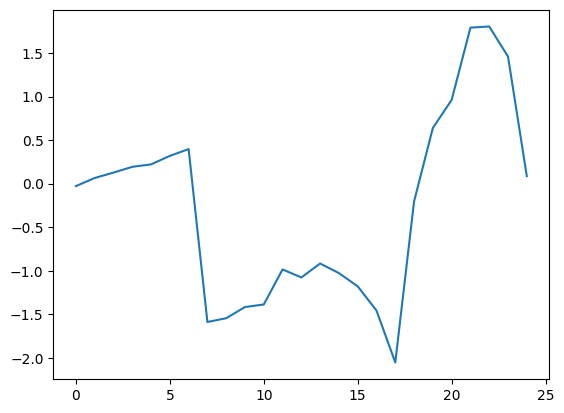

In [ ]:
with open("./prompts.json","r") as prompts_f:

    pf=json.load(prompts_f)

    layer_out_global_avg=[]

    for p_idx,prompt in enumerate(pf):

        text = prompt
        inputs = tokenizer(text, return_tensors="pt").to(device)

        outputs = model(**inputs)
        logits = outputs.logits  # shape: [batch, seq_len, vocab_size]

        # print(outputs.hidden_states)

        # un plot per layer
        # per ogni subplot: x->dimensioni per ogni token, y=token in input(parola)

        # Layer iniziali: token ancora legati a forma, vocabolario, sequenza
        # Layer medi: pattern semantici, relazioni tra token
        # Layer finali: rappresentazioni per la predizione del prossimo token 

        hidden_states=outputs.hidden_states

        num_layers = len(hidden_states)

        print("Layers: "+str(num_layers))
        print(hidden_states[0].shape)

        layer_out_avg=[0] * len(hidden_states)

        if len(layer_out_global_avg)==0:
            layer_out_global_avg=[0]*len(hidden_states)

        for idx,hs in enumerate(hidden_states):
            for hs_dim in hs:
                for hs_channels in hs_dim:
                    for hs_tokens in hs_channels:
                        hs_tokens_cpu = hs_tokens.detach().to("cpu").item()
                        layer_out_avg[idx]+=hs_tokens_cpu/(len(hs)*len(hs_dim)*len(hs_channels))

        for el_idx,el in enumerate(layer_out_avg):
            layer_out_global_avg[el_idx]+=layer_out_avg[el_idx]/len(hidden_states)

        print(layer_out_avg)

        seq_len = hidden_states[0].shape[1]

        plt.plot(range(len(hidden_states)),layer_out_avg)
        plt.savefig("./gpt_out/prompt_"+str(p_idx+1)+".png")
        plt.show()

plt.plot(range(len(layer_out_global_avg)),layer_out_global_avg)
plt.savefig("./gpt_out/global.png")
plt.show()

        # fig, axes = plt.subplots(
        #     nrows=num_layers,
        #     ncols=1,
        #     figsize=(12, 2 * num_layers),
        #     sharex=True
        # )

        # for i, ax in enumerate(axes):
        #     hs = hidden_states[i][0].detach().float().cpu().numpy()  # (seq_len, hidden_dim)
        #     sns.heatmap(
        #         hs,
        #         cmap="viridis",
        #         cbar=False,
        #         ax=ax
        #     )
        #     ax.set_ylabel(f"L{i}")

        # axes[-1].set_xlabel("Hidden dimension")
        # plt.suptitle("Hidden states across all layers", y=1.02)
        # plt.tight_layout()
        # plt.savefig("./gpt_assess_plot.png")
        # plt.show()


